In [9]:
%matplotlib inline

In [5]:
#pip install streamlit

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("wc_2026.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])
df.head()

,group,stage,team1,team2,venue,city,country,date,kickoff_et,team1_confederation,team1_fifa_rank,team1_coach,team2_confederation,team2_fifa_rank,team2_coach
0,A,Group Stage,Mexico,South Africa,Estadio Azteca,Mexico City,Mexico,2026-06-11,20:00 ET,CONCACAF,15.0,Javier Aguirre,CAF,60.0,Hugo Broos
1,A,Group Stage,South Korea,Czechia,Estadio Akron,Guadalajara,Mexico,2026-06-11,22:00 ET,AFC,25.0,Hong Myung-bo,UEFA,41.0,Ivan Hasek
2,A,Group Stage,South Korea,Mexico,Estadio Akron,Guadalajara,Mexico,2026-06-18,21:00 ET,AFC,25.0,Hong Myung-bo,CONCACAF,15.0,Javier Aguirre
3,A,Group Stage,Czechia,South Africa,Estadio Akron,Guadalajara,Mexico,2026-06-18,18:00 ET,UEFA,41.0,Ivan Hasek,CAF,60.0,Hugo Broos
4,A,Group Stage,Czechia,Mexico,Estadio Azteca,Mexico City,Mexico,2026-06-24,21:00 ET,UEFA,41.0,Ivan Hasek,CONCACAF,15.0,Javier Aguirre


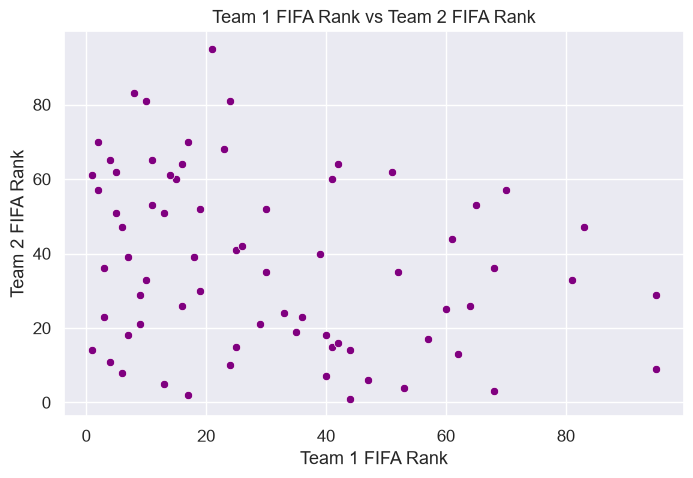

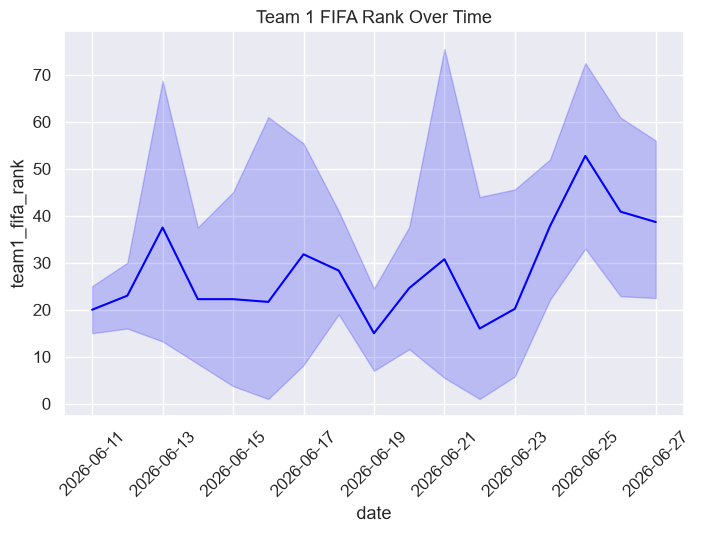

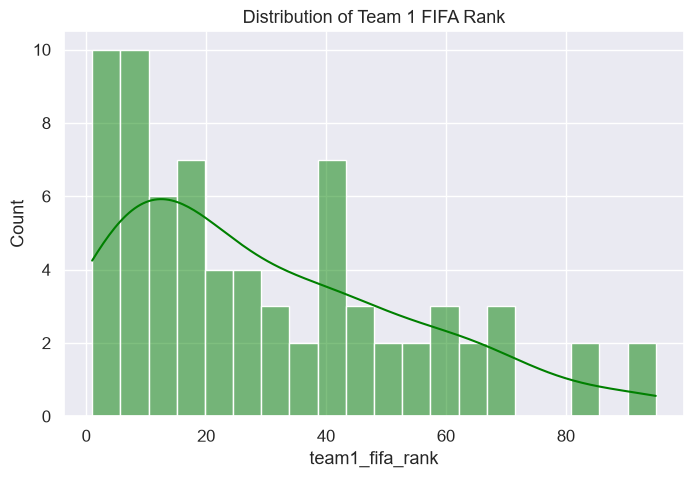

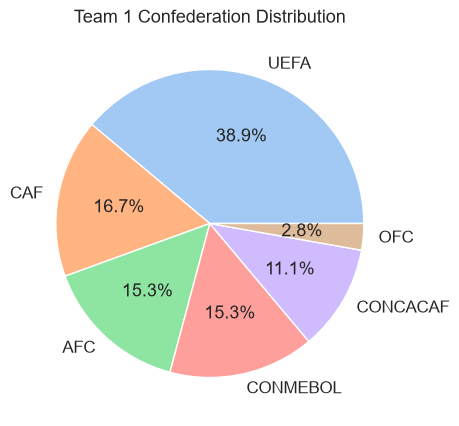

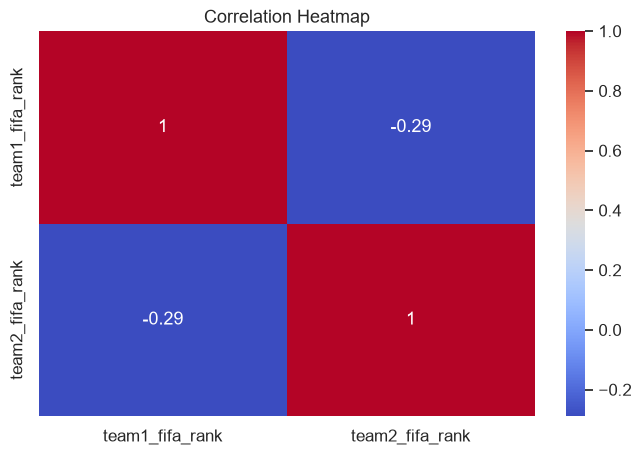

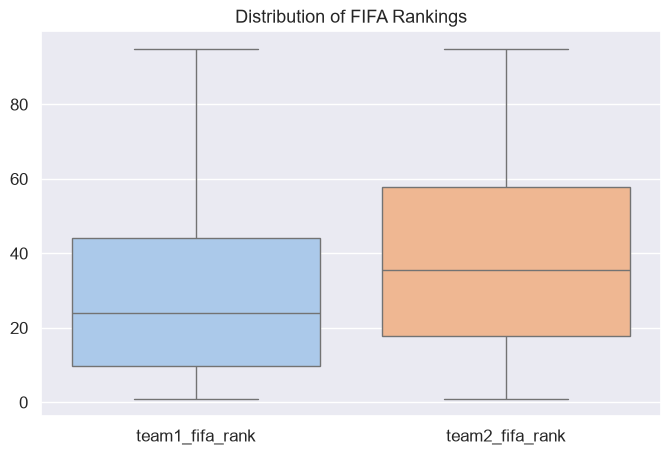

In [26]:
#Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="team1_fifa_rank",
    y="team2_fifa_rank",
    color="purple"
)
plt.title("Team 1 FIFA Rank vs Team 2 FIFA Rank")
plt.xlabel("Team 1 FIFA Rank")
plt.ylabel("Team 2 FIFA Rank")
plt.show()

#Line Plot
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x="date",
    y="team1_fifa_rank",
    color="blue"
)
plt.xticks(rotation=45)
plt.title("Team 1 FIFA Rank Over Time")
plt.show()

#Histogram
plt.figure(figsize=(8,5))
sns.histplot(
    df["team1_fifa_rank"],
    bins=20,
    kde=True,
    color="green"
)
plt.title("Distribution of Team 1 FIFA Rank")
plt.show()

#Pie Chart
conf_counts = df["team1_confederation"].value_counts()

plt.figure(figsize=(8,5))

plt.pie(
    conf_counts,
    labels=conf_counts.index,
    autopct="%1.1f%%"
)

plt.title("Team 1 Confederation Distribution")

plt.show()

#Heatmap
plt.figure(figsize=(8,5))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

#Box Plot
rank_df = df[
    ["team1_fifa_rank",
     "team2_fifa_rank"]
]

plt.figure(figsize=(8,5))

sns.boxplot(data=rank_df)

plt.title("Distribution of FIFA Rankings")

plt.show()

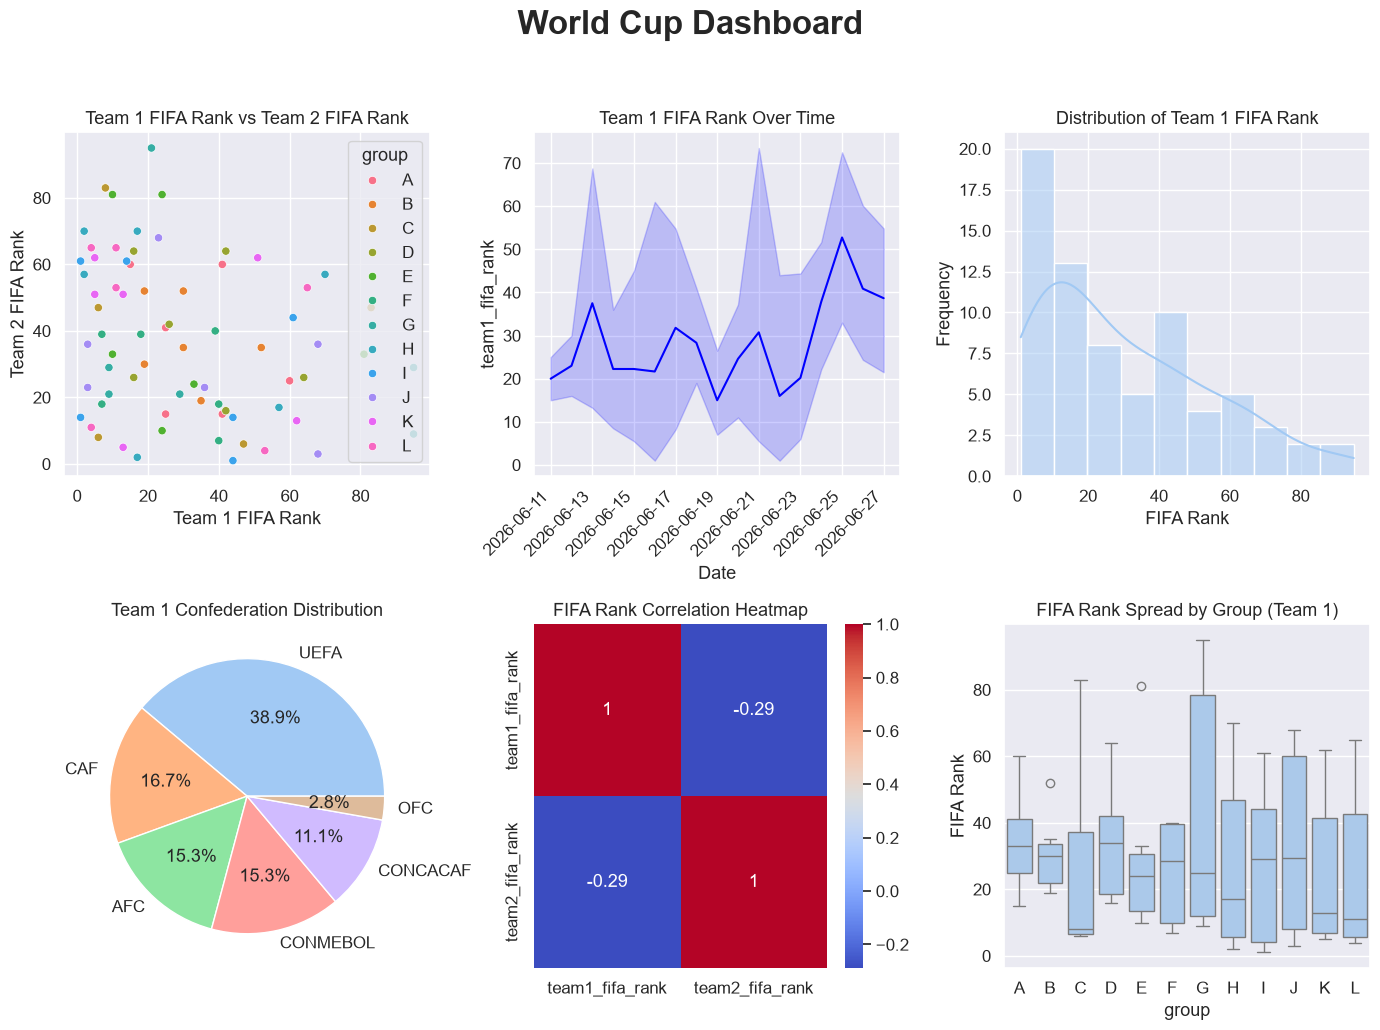

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

sns.set_theme(style= 'darkgrid', 
              palette= 'pastel',
              font= 'sans-serif',
              font_scale= 1.1,)

#Scatter Plot
sns.scatterplot(
    data=df,
    x='team1_fifa_rank',
    y='team2_fifa_rank',
    hue="group",
    palette="husl",
    ax=axes[0,0]
)

axes[0,0].set_title("Team 1 FIFA Rank vs Team 2 FIFA Rank")
axes[0,0].set_xlabel("Team 1 FIFA Rank")
axes[0,0].set_ylabel("Team 2 FIFA Rank")

#Line Plot
#Line Plot (Updated to Seaborn for the shaded confidence intervals)
sns.lineplot(
    data=df,
    x='date',
    y='team1_fifa_rank',
    color='blue',       # Matches the blue color line in your picture
    ax=axes[0,1]        # Targets the exact 1st row, 2nd column subplot
)

axes[0,1].set_title("Team 1 FIFA Rank Over Time")
axes[0,1].set_xlabel("Date")
axes[0,1].set_ylabel("team1_fifa_rank")

# Rotates and aligns the dates nicely so they do not overlap
axes[0,1].tick_params(axis='x', rotation=45)
for tick in axes[0,1].get_xticklabels():
    tick.set_horizontalalignment('right')


#Histogram
# Pass the specific subplot axis using the ax parameter
sns.histplot(
    data=df,
    x='team1_fifa_rank',
    bins=10,
    kde=True,
    ax=axes[0, 2]
)


axes[0,2].set_title("Distribution of Team 1 FIFA Rank")
axes[0,2].set_xlabel("FIFA Rank")
axes[0,2].set_ylabel("Frequency")

#Pie Chart
conf_counts = df["team1_confederation"].value_counts()

axes[1,0].pie(
    conf_counts,
    labels=conf_counts.index,
    autopct='%1.1f%%'
)

axes[1,0].set_title("Team 1 Confederation Distribution")

#Heatmap
corr = df[
    ['team1_fifa_rank','team2_fifa_rank']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    ax=axes[1,1]
)

axes[1,1].set_title("FIFA Rank Correlation Heatmap")

#Box Plot

sns.boxplot(
    data=df,
    x='group',
    y='team1_fifa_rank',
    ax=axes[1,2]
)

axes[1,2].set_title("FIFA Rank Spread by Group (Team 1)")
axes[1,2].set_ylabel("FIFA Rank")


plt.suptitle("World Cup Dashboard", 
             fontsize = 24,
             fontweight = 'bold',
             y = 1.03)


plt.tight_layout()
plt.show()